In [2]:
from google.colab import files

uploaded = files.upload()

Saving whatsapp_college_dataset.csv to whatsapp_college_dataset.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [4]:
df = pd.read_csv("whatsapp_college_dataset.csv")

df.head()

,sender_name,is_admin,group_name,timestamp,message,category,sentiment,urgency_score,response_time_minutes
0,Arun,True,Placement Updates,2026-05-19 09:15:00,Tomorrow Aptitude Test at 10 AM in Lab 3. Ever...,placement,positive,9,15
1,Priya,False,CSE Final Year,2026-05-19 10:20:00,Can someone send yesterday DBMS notes?,normal,neutral,2,120
2,Kavin,True,Placement Updates,2026-05-19 11:00:00,TCS interview results are announced. Check you...,placement,positive,8,20
3,Meena,False,AI Project Team,2026-05-19 11:45:00,Project review moved to Friday due to staff me...,project,neutral,5,60
4,Rahul,True,Exam Alerts,2026-05-19 12:10:00,Internal exam starts next Monday. Hall tickets...,exam,negative,9,10


In [5]:
X = df[["response_time_minutes"]]

y = df["urgency_score"]

model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [6]:
prediction = model.predict([[30]])

print("Predicted urgency score:", prediction)

Predicted urgency score: [7.4408951]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


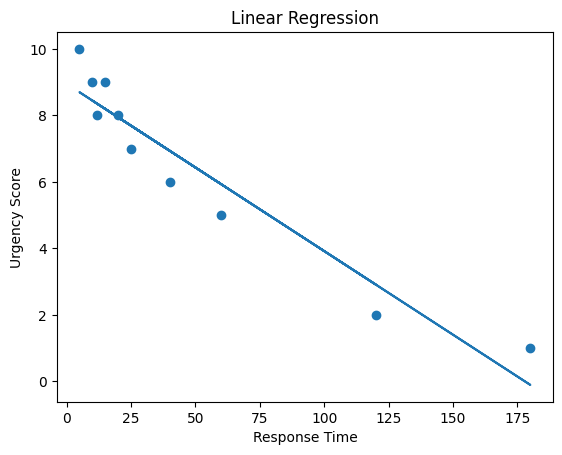

In [7]:
plt.scatter(X, y)

plt.plot(X, model.predict(X))

plt.xlabel("Response Time")

plt.ylabel("Urgency Score")

plt.title("Linear Regression")

plt.show()

In [8]:
df["is_admin"] = df["is_admin"].astype(int)

df.head()

,sender_name,is_admin,group_name,timestamp,message,category,sentiment,urgency_score,response_time_minutes
0,Arun,1,Placement Updates,2026-05-19 09:15:00,Tomorrow Aptitude Test at 10 AM in Lab 3. Ever...,placement,positive,9,15
1,Priya,0,CSE Final Year,2026-05-19 10:20:00,Can someone send yesterday DBMS notes?,normal,neutral,2,120
2,Kavin,1,Placement Updates,2026-05-19 11:00:00,TCS interview results are announced. Check you...,placement,positive,8,20
3,Meena,0,AI Project Team,2026-05-19 11:45:00,Project review moved to Friday due to staff me...,project,neutral,5,60
4,Rahul,1,Exam Alerts,2026-05-19 12:10:00,Internal exam starts next Monday. Hall tickets...,exam,negative,9,10


In [9]:
X_multi = df[["is_admin", "urgency_score"]]

y_multi = df["response_time_minutes"]

multi_model = LinearRegression()

multi_model.fit(X_multi, y_multi)

LinearRegression()

In [10]:
prediction_multi = multi_model.predict([[1, 9]])

print("Predicted response time:", prediction_multi)

Predicted response time: [2.21492537]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [11]:
print("Linear Regression Score:", model.score(X, y))

print("Multiple Regression Score:", multi_model.score(X_multi, y_multi))

Linear Regression Score: 0.9145177180416308
Multiple Regression Score: 0.9155317463103747


In [12]:
import pickle

# Save model
with open("linear_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Linear Regression Model Saved")

Linear Regression Model Saved


In [13]:
with open("linear_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model Loaded Successfully")

Model Loaded Successfully


In [14]:
import pandas as pd

test_data = pd.DataFrame({
    "response_time_minutes": [45]
})

prediction = loaded_model.predict(test_data)

print("Prediction:", prediction)

Prediction: [6.68616641]


In [15]:
import joblib

# Save model
joblib.dump(multi_model, "multiple_regression_model.joblib")

print("Multiple Regression Model Saved")

Multiple Regression Model Saved


In [16]:
loaded_multi_model = joblib.load("multiple_regression_model.joblib")

print("Joblib Model Loaded")

Joblib Model Loaded


In [17]:
new_data = pd.DataFrame({
    "is_admin": [1],
    "urgency_score": [8]
})

prediction = loaded_multi_model.predict(new_data)

print("Predicted Response Time:", prediction)

Predicted Response Time: [19.94626866]


In [20]:
from google.colab import files

files.download("linear_model.pkl")
files.download("multiple_regression_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import os

print(os.listdir("/content"))

['.config', 'multiple_regression_model.joblib', 'linear_model.pkl', 'whatsapp_college_dataset.csv', 'sample_data']
